In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("sui_factura_promedio_consolidado.csv")

## Objetivo del analisis

En este EDA la variable objetivo es `Factura_Promedio_COP`, por lo que el problema se puede leer como uno de regresion. La idea es identificar que variables parecen explicar mejor su comportamiento y que aspectos del dataset habria que tener en cuenta antes de una etapa de modelado.

Revisar el tamaño del DataFrame (filas, columnas)

In [28]:
df.shape

(5809, 6)

`df.shape` muestra el tamaño del DataFrame en formato `(filas, columnas)`. En este caso se usa para confirmar cuántos registros y cuántas variables tiene el dataset consolidado antes de seguir con el análisis.

In [29]:
df.head()

,Empresa,Anio,Mes,Periodo,Segmento,Factura_Promedio_COP
0,AIR-E S.A.S. E.S.P.,2025,1,2025-01,Estrato 1,273094.53
1,CARIBEMAR DE LA COSTA S.A.S. E.S.P.,2025,1,2025-01,Estrato 1,200250.84
2,CELSIA COLOMBIA S.A. E.S.P.,2025,1,2025-01,Estrato 1,87115.06
3,CENTRALES ELECTRICAS DEL NORTE DE SANTANDER S....,2025,1,2025-01,Estrato 1,119172.97
4,CENTRALES ELECTRICAS DE NARIÑO S.A. E.S.P.,2025,1,2025-01,Estrato 1,72510.58


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5809 entries, 0 to 5808
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Empresa               5809 non-null   str    
 1   Anio                  5809 non-null   int64  
 2   Mes                   5809 non-null   int64  
 3   Periodo               5809 non-null   str    
 4   Segmento              5809 non-null   str    
 5   Factura_Promedio_COP  5809 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 272.4 KB


In [31]:
df.describe()

,Anio,Mes,Factura_Promedio_COP
count,5809.000000,5809.000000,5.809000e+03
mean,2025.179205,5.619039,3.206632e+07
std,0.383557,3.586590,1.456852e+08
min,2025.000000,1.000000,-8.444811e+05
25%,2025.000000,2.000000,1.171532e+05
50%,2025.000000,5.000000,4.531160e+05
75%,2025.000000,9.000000,3.406443e+06
max,2026.000000,12.000000,1.969094e+09


Con un promedio mayor que la media, se puede pensar que hay valores muy altos que estan arrastrandoel promedio a que se tenga ese resultado con respecto a la media

In [32]:
df[df["Factura_Promedio_COP"] < 0]

,Empresa,Anio,Mes,Periodo,Segmento,Factura_Promedio_COP
3934,ELECTRIFICADORA DE SANTANDER S.A. E.S.P.,2025,10,2025-10,Otros,-844481.09


Se identifican valores negativos en el promedio de la factura, se debe revisar debido a que puede estar teniendo ese valor negativo  (ajustes contables, devoluciones,subsidios reportados de forma especial, errores de reporte)

In [33]:
df.isnull().sum()

Empresa                 0
Anio                    0
Mes                     0
Periodo                 0
Segmento                0
Factura_Promedio_COP    0
dtype: int64

In [34]:
(df.isnull().sum()/len(df))*100

Empresa                 0.0
Anio                    0.0
Mes                     0.0
Periodo                 0.0
Segmento                0.0
Factura_Promedio_COP    0.0
dtype: float64

Verificamos que no tengamos null debido a los resultados anteriores que puedan estar sesgando el resultado

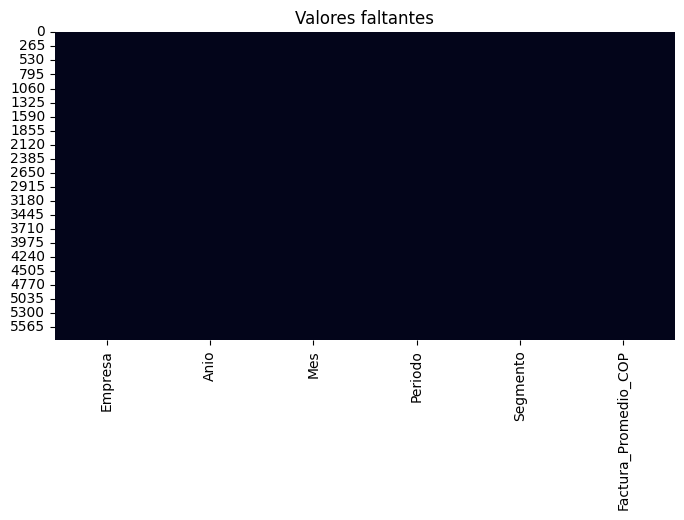

In [35]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Valores faltantes")
plt.show()

No se identificaron valores faltantes después del proceso ETL.

In [36]:
df.duplicated().sum()

np.int64(0)

No se encontraron registros duplicados.

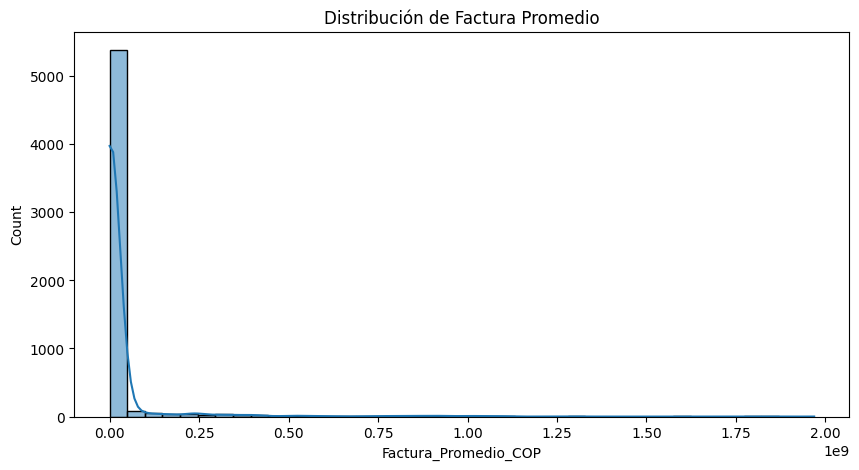

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Factura_Promedio_COP"],
    bins=40,
    kde=True
)

plt.title("Distribución de Factura Promedio")
plt.show()

En el analisis de la campana de Gaus obtenemos : Cola larga a la derecha, lo que nos indica que tenemos una distribucion con asimetria positiva, lo cual puede ser representado por tener un dataset de facturacion

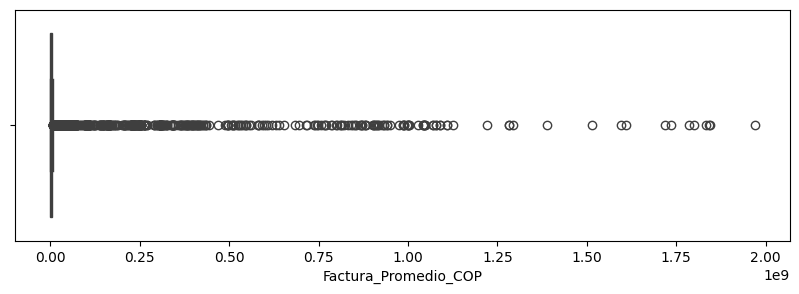

In [38]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["Factura_Promedio_COP"]
)

plt.show()

Vemos que hay empresas con facturas mucho mayores al promedio

In [39]:
df["Empresa"].nunique()

52

In [40]:
df["Empresa"].value_counts().head(15)

Empresa
CELSIA COLOMBIA S.A. E.S.P.                                                       180
CENTRALES ELECTRICAS DEL NORTE DE SANTANDER S.A. ESP                              180
CENTRAL HIDROELECTRICA DE CALDAS S.A. E.S.P. BIC BENEFICIO E INTERES COLECTIVO    180
COMPAÑÍA DE ELECTRICIDAD DE TULUÁ S.A. E.S.P.                                     180
ELECTRIFICADORA DEL META S.A. E.S.P.                                              180
ELECTRIFICADORA DE SANTANDER S.A. E.S.P.                                          180
EMPRESA DE ENERGIA DE BOYACA S.A. E.S.P. EMPRESA DE SERVICIOS PUBLICOS            180
EMPRESAS MUNICIPALES DE CALI   E.I.C.E  E.S.P                                     180
EMPRESAS PÚBLICAS DE MEDELLIN E.S.P.                                              180
ENEL COLOMBIA S.A. E.S.P.                                                         180
VATIA S.A.S. E.S.P.                                                               180
AIR-E S.A.S. E.S.P.                           

Identificamos que no todos los segmentos tienen la misma cantidad de registros

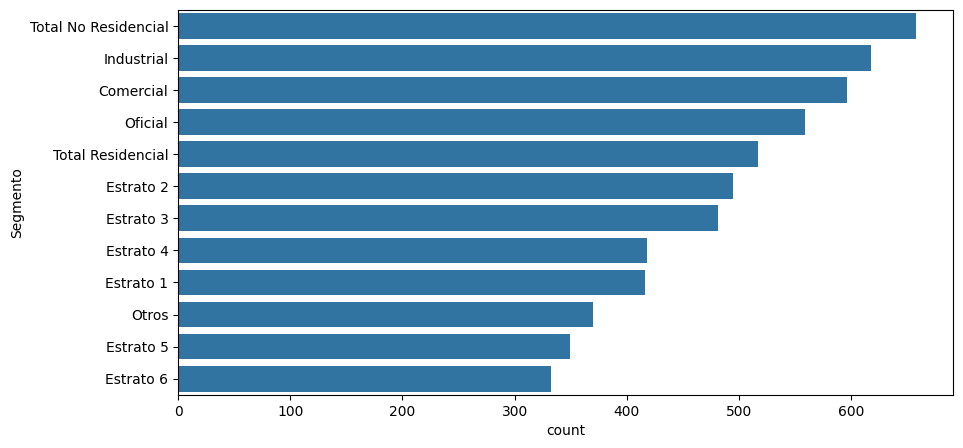

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Segmento",
    order=df["Segmento"].value_counts().index
)

plt.show()

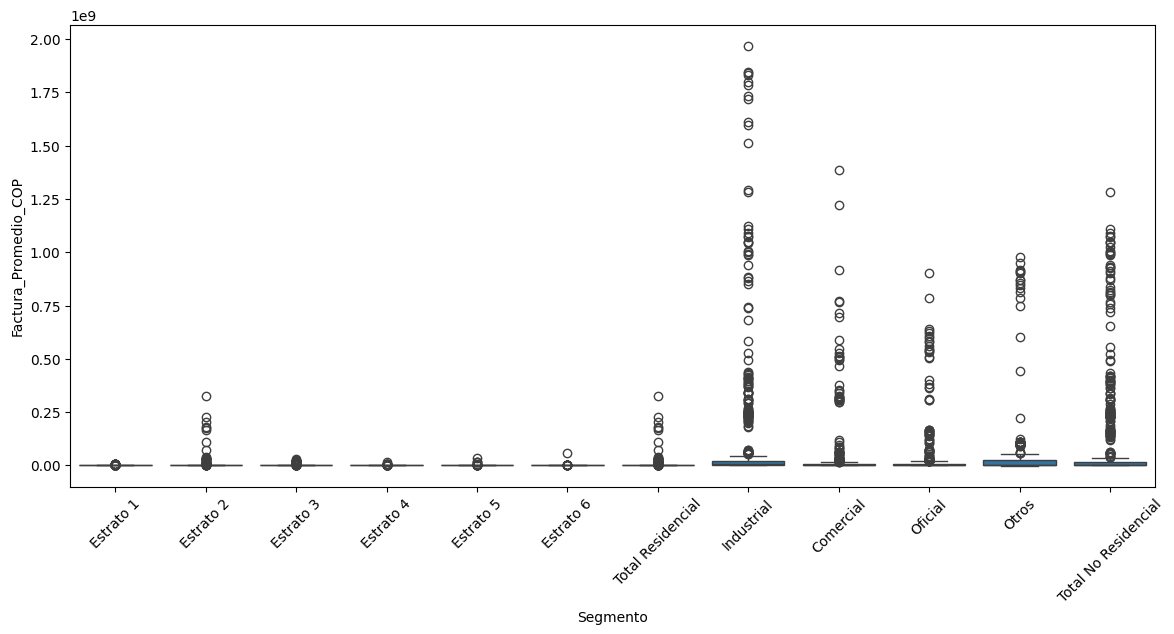

In [42]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Segmento",
    y="Factura_Promedio_COP"
)

plt.xticks(rotation=45)
plt.show()

El segmento industrial se evidencia que tiene facturas mas altas al resto de los segmentos

## Analisis complementario

En los siguientes bloques se profundiza el analisis con tres enfoques: empresas con mayores promedios, evolucion temporal del indicador y comparacion entre segmentos. Esto sirve para pasar de una revision descriptiva general a hallazgos mas concretos sobre comportamiento del mercado.

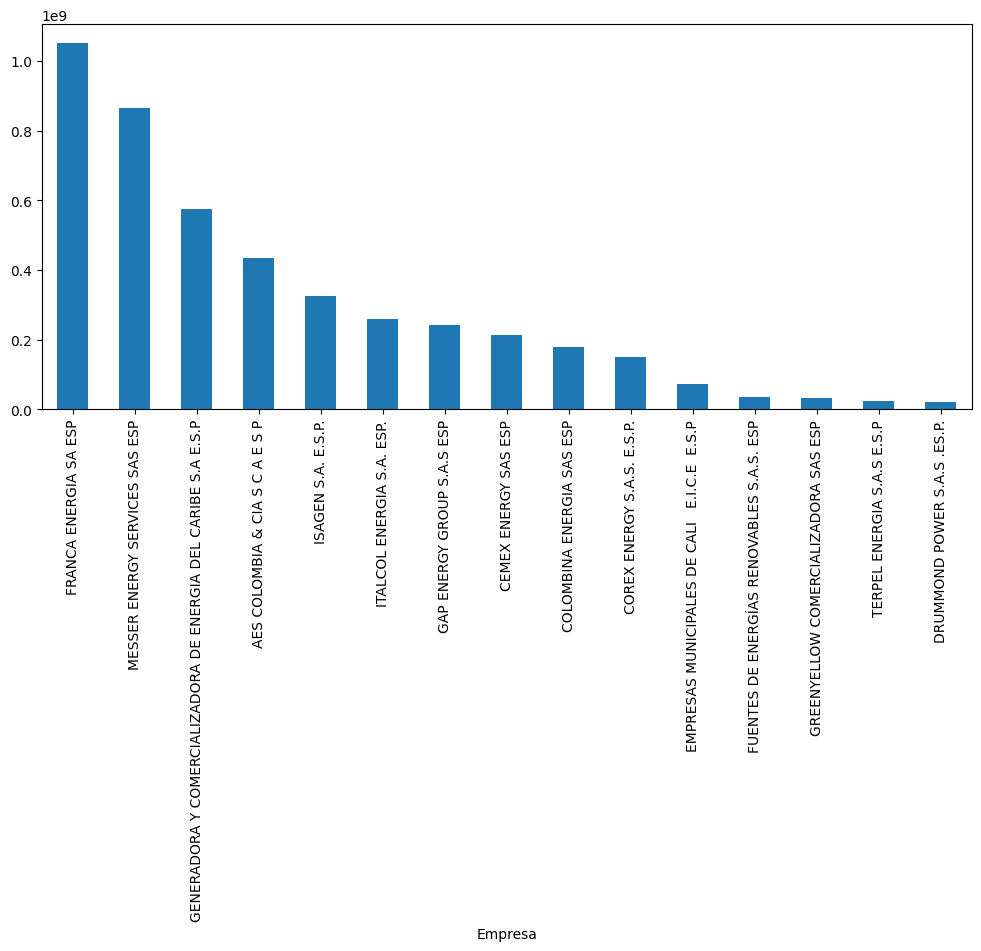

In [43]:
ranking = (
    df.groupby("Empresa")
        ["Factura_Promedio_COP"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
)

ranking.plot(
    kind="bar",
    figsize=(12,5)
)

plt.show()

Aqui se agrupa la informacion por empresa y se calcula el promedio de `Factura_Promedio_COP`, para luego graficar las 15 empresas con valores mas altos. Esto ayuda a identificar que parte de la asimetria del dataset viene explicada por unas pocas empresas con montos muy superiores al resto.

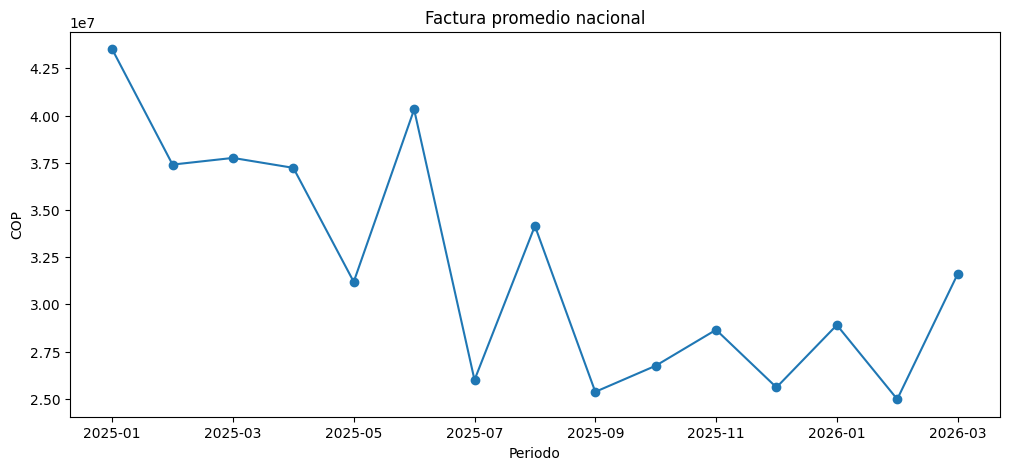

In [44]:
serie = (
    df.groupby("Periodo")
        ["Factura_Promedio_COP"]
        .mean()
)

plt.figure(figsize=(12,5))

serie.plot(marker="o")

plt.title("Factura promedio nacional")
plt.ylabel("COP")

plt.show()

En esta serie se calcula el promedio general por periodo para observar si existe una tendencia clara en el tiempo. El resultado muestra variaciones mes a mes, con picos visibles al inicio de 2025 y en junio de 2025, pero sin una relacion lineal fuerte entre el paso del tiempo y el valor de la factura promedio.

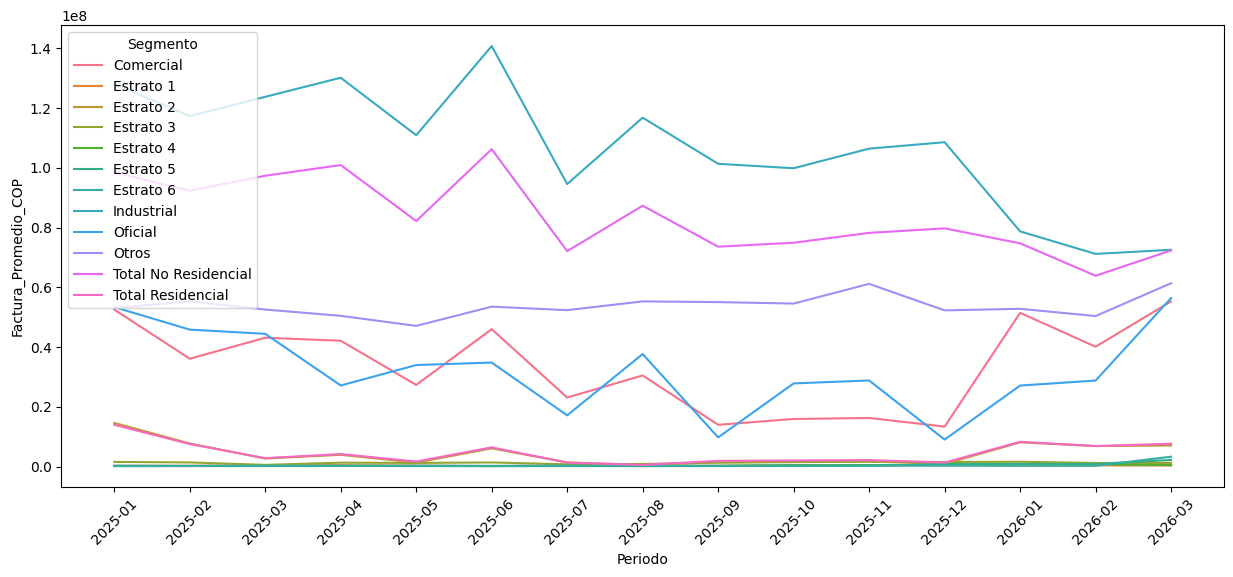

In [45]:
segmentos_mes = (
    df.groupby(
        ["Periodo","Segmento"]
    )["Factura_Promedio_COP"]
        .mean()
        .reset_index()
)

plt.figure(figsize=(15,6))

sns.lineplot(
    data=segmentos_mes,
    x="Periodo",
    y="Factura_Promedio_COP",
    hue="Segmento"
)

plt.xticks(rotation=45)
plt.show()

Aqui se compara la evolucion del promedio por segmento en cada periodo. Este grafico permite ver que los segmentos no residenciales, en especial `Industrial`, se mueven en niveles mucho mas altos que los residenciales, lo que confirma que comparar todo el dataset con una sola media puede ocultar diferencias importantes entre grupos.

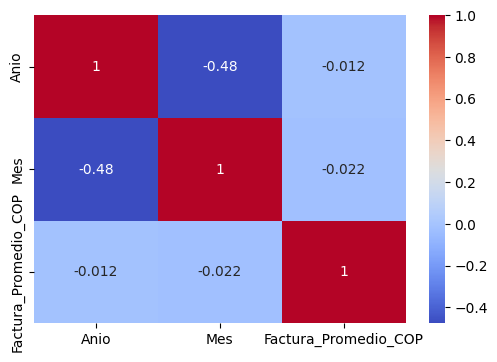

In [46]:
corr = df[
    ["Anio", "Mes", "Factura_Promedio_COP"]
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
 )

plt.show()

La matriz de correlacion revisa si `Anio`, `Mes` y `Factura_Promedio_COP` tienen una relacion lineal marcada. En este caso la correlacion con el tiempo es casi nula, por lo que los cambios observados parecen depender mas de diferencias entre empresas y segmentos que de una tendencia temporal simple.

Para complementar esta idea, a continuacion se calcula una medida de asociacion entre la facturacion y otras variables del dataset. Esto permite comparar que tanto ayudan `Empresa`, `Segmento`, `Periodo`, `Mes` y `Anio` a explicar la variabilidad de `Factura_Promedio_COP`.

Los scatterplots mantienen la misma lectura de la matriz de correlacion: no se observa una pendiente clara ni una estructura temporal simple que explique la facturacion. La nube de puntos esta muy dispersa, lo que sugiere que el tiempo por si solo no basta para describir el comportamiento del target.

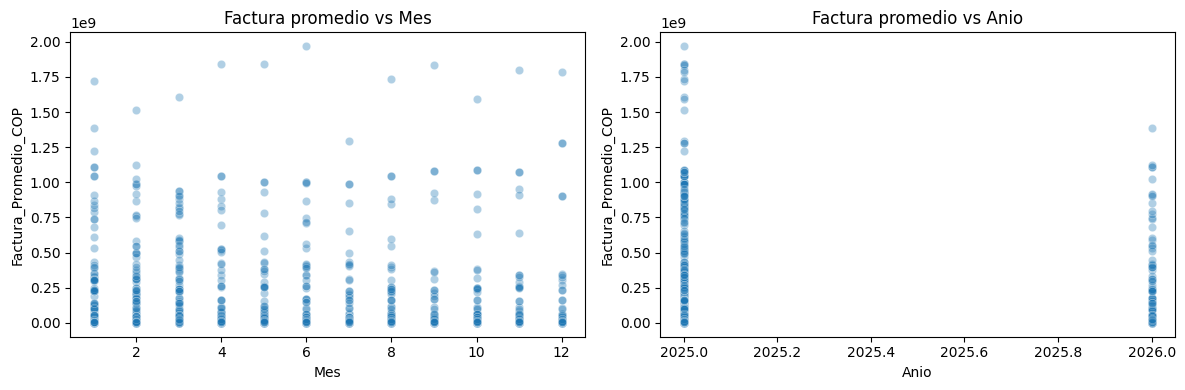

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=df,
    x="Mes",
    y="Factura_Promedio_COP",
    alpha=0.35,
    ax=axes[0]
 )
axes[0].set_title("Factura promedio vs Mes")

sns.scatterplot(
    data=df,
    x="Anio",
    y="Factura_Promedio_COP",
    alpha=0.35,
    ax=axes[1]
 )
axes[1].set_title("Factura promedio vs Anio")

plt.tight_layout()
plt.show()

Para reforzar esa conclusion, a continuacion se agregan scatterplots simples entre el target y las variables temporales numericas. Aunque `Mes` y `Anio` no son variables muy ricas por si solas, sirven para verificar visualmente si existe alguna tendencia evidente que la correlacion pudiera estar escondiendo.

Empresa     0.684941
Segmento    0.067572
Periodo     0.001631
Mes         0.001007
Anio        0.000136
dtype: float64


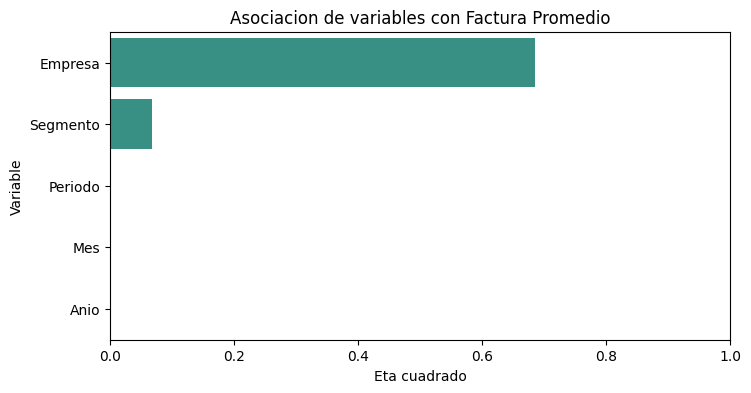

In [48]:
def eta_squared(data, group_col, value_col):
    resumen = data.groupby(group_col)[value_col].agg(["mean", "count"])

    media_global = data[value_col].mean()
    ss_between = ((resumen["mean"] - media_global) ** 2 * resumen["count"]).sum()
    ss_total = ((data[value_col] - media_global) ** 2).sum()

    return ss_between / ss_total if ss_total else 0

asociacion = pd.Series(
    {
        "Empresa": eta_squared(df, "Empresa", "Factura_Promedio_COP"),
        "Segmento": eta_squared(df, "Segmento", "Factura_Promedio_COP"),
        "Periodo": eta_squared(df, "Periodo", "Factura_Promedio_COP"),
        "Mes": eta_squared(df, "Mes", "Factura_Promedio_COP"),
        "Anio": eta_squared(df, "Anio", "Factura_Promedio_COP"),
    }
).sort_values(ascending=False)

print(asociacion)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=asociacion.values,
    y=asociacion.index,
    color="#2a9d8f"
 )

plt.title("Asociacion de variables con Factura Promedio")
plt.xlabel("Eta cuadrado")
plt.ylabel("Variable")
plt.xlim(0, 1)
plt.show()

## Hallazgos del EDA y decisiones para modelado

### Hallazgos principales

- El dataset consolidado tiene buena calidad estructural para el analisis: no se observan valores nulos ni registros duplicados despues del ETL.
- `Factura_Promedio_COP` presenta una distribucion fuertemente asimetrica hacia la derecha, con outliers altos que elevan de forma importante la media.
- Los segmentos no residenciales, especialmente `Industrial`, concentran los valores mas altos y la mayor dispersion.
- `Total Residencial` y `Total No Residencial` no son segmentos base, sino categorias agregadas que ya vienen en la fuente del SUI. Por eso deben interpretarse con cuidado: resumen parte de la informacion de otros segmentos y pueden influir en medias, dispersiones y comparaciones si se analizan junto con categorias mas especificas.
- La relacion de la facturacion con el tiempo es debil. Tanto la matriz de correlacion como los scatterplots muestran que `Mes` y `Anio` no explican por si solos el comportamiento del target.
- Las variables con mayor asociacion con `Factura_Promedio_COP` son `Empresa` y `Segmento`, por encima de `Periodo`, `Mes` y `Anio`.

### Cierre frente al modelado

- Variable objetivo: `Factura_Promedio_COP`.
- Tipo de problema: regresion.
- Variables con mayor relacion con el target: `Empresa` y `Segmento`.
- Variables temporales con menor aporte directo: `Mes` y `Anio`.
- Variable redundante: `Periodo`, porque se construye a partir de `Anio` y `Mes`. Si se usan estas dos variables, `Periodo` no deberia entrar al modelo al mismo tiempo.
- Variable que requiere transformacion: `Factura_Promedio_COP`, ya que su asimetria y presencia de outliers sugieren evaluar transformaciones como `log1p` o enfoques robustos. Antes de eso se debe resolver el caso puntual del valor negativo.
- Variable categorica apta para codificacion: `Segmento`. Si se pasa a una etapa de modelado, podria representarse con tecnicas como one-hot encoding porque tiene pocas categorias y una interpretacion clara.
- Variable que requiere tratamiento especial: `Empresa`, porque tiene alta cardinalidad. En este caso no seria recomendable aplicar one-hot encoding de forma directa sin antes evaluar su impacto; para modelado puede requerir agrupacion, codificacion por frecuencia, target encoding o exclusion segun el enfoque.
- Sobre `Total Residencial` y `Total No Residencial`: para el EDA se conservaron porque hacen parte del reporte oficial y ayudan a entender como viene estructurada la informacion del SUI. Sin embargo, para un modelo enfocado en segmentos base, lo mas recomendable seria excluirlos para no mezclar categorias agregadas con categorias especificas.
- Sobre desbalance de clases: no aplica de forma estricta porque no es un problema de clasificacion. Sin embargo, si hay desbalance en la cantidad de registros por segmento, lo cual puede influir en el aprendizaje del modelo.

### Variables sugeridas para un primer modelado

Como punto de partida, las variables que tienen mas sentido para un modelo base son `Segmento`, `Empresa`, `Mes` y `Anio`, dejando por fuera `Periodo` para evitar redundancia. Aun asi, `Empresa` deberia tratarse con cuidado por su cardinalidad y el target deberia revisarse para manejar su asimetria antes de entrenar cualquier modelo.

Si el objetivo es construir un modelo mas limpio y comparable entre segmentos especificos, conviene trabajar con una version del dataset sin `Total Residencial` y `Total No Residencial`. Si el objetivo fuera reproducir exactamente cualquier valor reportado por el SUI, entonces podria justificarse mantenerlos, pero dejandolos claramente identificados como observaciones agregadas.

### Consideraciones finales del ETL

El ETL deja un consolidado util para analisis y modelado porque elimina filas de contexto, limpia nombres de empresa, convierte los valores faltantes del reporte original a nulos y luego conserva solo observaciones con dato numerico. Eso mejora la calidad del dataset, pero tambien explica por que algunos segmentos tienen menos registros que otros. Ademas, permanece un caso puntual de valor negativo que conviene revisar antes de cualquier etapa predictiva.